## Kernel to load: vax_inc_general 

In [1]:
import pandas as pd
import numpy as np
import pycountry
import pickle
from docx import Document
from docx.enum.text import WD_PARAGRAPH_ALIGNMENT
from docx.shared import Pt
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import math
import jenkspy
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import make_interp_spline
import sys,os

In [2]:
notebook_dir = os.path.dirname(os.getcwd())
source_data_path=os.path.join(notebook_dir, "Common Source Data")
sys.path.append(source_data_path)
from country_codes import countries

In [3]:
df=pd.read_csv('Supplementary Spreadsheet- Vaccination Coverage Estimates.csv')
df_incidence= pd.read_csv(os.path.join(notebook_dir, 'Disease Incidence/Supplementary Spreadsheet- Incidence Estimates.csv'))
df["Vaccination Coverage (%)"] = df["Vaccination Coverage (%)"].clip(upper=100)
df["Vaccination Coverage (%) Upper"] = df["Vaccination Coverage (%) Upper"].clip(upper=100)

# Duplicating 'newcastle disease (velogenic)' and assigning as 'newcastle disease' (for easy comparison)
   # between the vaccination coverage dataframe and incidence dataframe for newcastle disease if desired 
mask = df_incidence['Disease'].str.contains('castle', case=False, na=False)

dup_rows = df_incidence.loc[mask].copy()

#Changing the "Disease" column in the duplicated rows to "Newcastle disease"
dup_rows['Disease'] = 'Newcastle disease'

# Appending the duplicated rows to df_incidence
df_incidence = pd.concat([df_incidence, dup_rows], ignore_index=True)


In [4]:
df=df.merge(df_incidence.drop(columns=['Country']),on=['ISO3','Year','Animal','Disease'],how='left')

In [5]:
pop_countries_cattle = df['ISO3']

for row in df.iterrows():
    if (row[1]['Country']==row[1]['Country']):
        countries[row[1]['ISO3']]=row[1]['Country']

codes_pop_cattle = [countries.get(country, 'Unknown code:'+country) for country in pop_countries_cattle]

iso3s_pop_cattle=[]

for i in pop_countries_cattle:
    try:
        iso3s_pop_cattle+=[countries[i]]
    except:
        iso3s_pop_cattle+=[None]
        
df['Country']=iso3s_pop_cattle


print(np.unique(codes_pop_cattle)) 

['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola' 'Argentina'
 'Armenia' 'Aruba' 'Australia' 'Austria' 'Azerbaijan' 'Bahrain'
 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bhutan'
 'Bolivia, Plurinational State of' 'Bosnia and Herzegovina' 'Botswana'
 'Brazil' 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso' 'Burundi'
 'Cambodia' 'Cameroon' 'Canada' 'Cape Verde' 'Cayman Islands'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia' 'Comoros'
 'Congo' 'Congo, The Democratic Republic of the' 'Cook Islands'
 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus' 'Czechia' "Côte d'Ivoire"
 'Denmark' 'Djibouti' 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador'
 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia'
 'Falkland Islands (Malvinas)' 'Faroe Islands' 'Fiji' 'Finland' 'France'
 'French Guiana' 'French Polynesia' 'Gabon' 'Gambia' 'Georgia' 'Germany'
 'Ghana' 'Greece' 'Greenland' 'Grenada' 'Guadeloupe' 'Guatemala' 'Guinea'
 'Guinea-Bissau' 'Guyana' 'Haiti' 'Hondu

In [6]:
df=df.sort_values(['Country','Animal','Disease'])

In [7]:
df_pop_cattle=pd.read_csv(os.path.join(source_data_path,'Processed Data','FAO Populations','cattle_pop.csv'))
df_pop_cattle = df_pop_cattle.sort_values('Value').drop_duplicates(subset=['ISO3','Year','Item'], keep='last').loc[:,['Area','Value','ISO3','Year']]
df_pop_cattle=df_pop_cattle.sort_values('Year').loc[:,['Area','Value','ISO3','Year']]
df_pop_cattle['Animal']=['Cattle']*df_pop_cattle.shape[0]
df_pop_cattle.rename(columns={'Value':'latest pop'},inplace=True)


df_pop_poultry=pd.read_csv(os.path.join(source_data_path,'Processed Data','FAO Populations','poultry_pop.csv'))
df_pop_poultry = df_pop_poultry.sort_values('Value').drop_duplicates(subset=['ISO3','Year','Item'], keep='last')
df_pop_poultry = (
    df_pop_poultry.groupby(['ISO3', 'Year Code'], as_index=False)
    .agg({
        'Domain Code': 'first',
        'Domain': 'first',
        'Area Code (M49)': 'first',
        'Area': 'first',
        'Element Code': 'first',
        'Element': 'first',
        'Item Code (CPC)': 'first',
        'Year Code': 'first',
        'Year': 'first',
        'Unit': 'first',
        'Value': 'sum',  
        'Flag': 'first',
        'Flag Description': 'first',
        'Note': 'first',
        'ISO3':'first'
    })
)
df_pop_poultry['Item'] = 'Poultry'
df_pop_poultry=df_pop_poultry.sort_values('Year').loc[:,['Area','Value','ISO3','Year']]
df_pop_poultry.rename(columns={'Value':'latest pop'},inplace=True)
df_pop_poultry['Animal']=['Poultry']*df_pop_poultry.shape[0]
df_pop_poultry['latest pop']*=1000

df_pop_swine=pd.read_csv(os.path.join(source_data_path,'Processed Data','FAO Populations','swine_pop.csv'))
df_pop_swine = df_pop_swine.sort_values('Value').drop_duplicates(subset=['ISO3','Year','Item'], keep='last')
df_pop_swine=df_pop_swine.sort_values('Year').loc[:,['Area','Value','ISO3','Year']]
df_pop_swine.rename(columns={'Value':'latest pop'},inplace=True)
df_pop_swine['Animal']=['Pigs']*df_pop_swine.shape[0]


df_pop_killed_cattle=pd.read_csv(os.path.join(source_data_path,'Processed Data','FAO Populations','killed_cattle_pop.csv'))
df_pop_killed_cattle = df_pop_killed_cattle.sort_values('Value').drop_duplicates(subset=['ISO3','Year','Item'], keep='last')
df_pop_killed_cattle.rename(columns={'Value':'latest pop'},inplace=True)
df_pop_killed_cattle=df_pop_killed_cattle.sort_values('Year').loc[:,['Area','latest pop','ISO3','Year']]
df_pop_killed_cattle['Animal']=['Cattle']*df_pop_killed_cattle.shape[0]

df_pop_killed_poultry=pd.read_csv(os.path.join(source_data_path,'Processed Data','FAO Populations','killed_poultry_pop.csv'))
df_pop_killed_poultry = df_pop_killed_poultry.sort_values('Value').drop_duplicates(subset=['ISO3','Year','Item'], keep='last')
df_pop_killed_poultry = (
    df_pop_killed_poultry.groupby(['ISO3', 'Year Code'], as_index=False)
    .agg({
        'Domain Code': 'first',
        'Domain': 'first',
        'Area Code (M49)': 'first',
        'Area': 'first',
        'Element Code': 'first',
        'Element': 'first',
        'Item Code (CPC)': 'first',
        'Year Code': 'first',
        'Year': 'first',
        'Unit': 'first',
        'Value': 'sum', 
        'Flag': 'first',
        'Flag Description': 'first',
        'Note': 'first',
        'ISO3':'first'
    })
)
df_pop_killed_poultry['Item'] = 'Poultry'
df_pop_killed_poultry=df_pop_killed_poultry.sort_values('Year').loc[:,['Area','Value','ISO3','Year']]
df_pop_killed_poultry.rename(columns={'Value':'latest pop'},inplace=True)
df_pop_killed_poultry['Animal']=['Poultry']*df_pop_killed_poultry.shape[0]
df_pop_killed_poultry['latest pop']*=1000

df_pop_killed_swine=pd.read_csv(os.path.join(source_data_path,'Processed Data','FAO Populations','killed_swine_pop.csv'))
df_pop_killed_swine = df_pop_killed_swine.sort_values('Value').drop_duplicates(subset=['ISO3','Year','Item'], keep='last')
df_pop_killed_swine=df_pop_killed_swine.sort_values('Year').loc[:,['Area','Value','ISO3','Year']]
df_pop_killed_swine.rename(columns={'Value':'latest pop'},inplace=True)
df_pop_killed_swine['Animal']=['Pigs']*df_pop_killed_swine.shape[0]

In [8]:
df_pops=pd.concat([df_pop_cattle,df_pop_poultry,df_pop_swine]).drop(columns=['Area'])
df_killed_pops=pd.concat([df_pop_killed_cattle,df_pop_killed_poultry,df_pop_killed_swine]).drop(columns=['Area'])
df_killed_pops.rename(columns={'latest pop':'killed pop'},inplace=True)

In [9]:
df_calculations_vacc=df.merge(df_pops,how='left',on=['ISO3','Animal','Year'])
df_calculations_vacc=df_calculations_vacc.merge(df_killed_pops,how='left',on=['ISO3','Animal','Year'])


In [10]:
df_calculations_vacc['total pop']=df_calculations_vacc['latest pop']+df_calculations_vacc['killed pop']

In [11]:

df_calculations_vacc['Number of Vaccinated Lower']=df_calculations_vacc['Vaccination Coverage (%) Lower']/100*df_calculations_vacc['total pop']
df_calculations_vacc['Number of Vaccinated Upper']=df_calculations_vacc['Vaccination Coverage (%) Upper']/100*df_calculations_vacc['total pop']
df_calculations_vacc['Number of Vaccinated Estimate']=df_calculations_vacc['Vaccination Coverage (%)']/100*df_calculations_vacc['total pop']
df_calculations_vacc=df_calculations_vacc[~df_calculations_vacc.loc[:,['Number of Vaccinated Lower','Number of Vaccinated Upper','Number of Vaccinated Estimate','total pop']].isna().all(1)]




susceptible_countries_per_disease_df=pd.read_csv(os.path.join(notebook_dir,'Common Source Data','Processed data','Multisource','domestic_disease_presence_or_absence_filter.csv'))

df_calculations_vacc=df_calculations_vacc.merge(susceptible_countries_per_disease_df,on=['ISO3','Year','Disease'], how ='left')

In [12]:
with open(os.path.join(source_data_path, 'Processed data','WAHIS data','vaccines_sorted_by_use.pickle'), 'rb') as handle:
    _,_,_,top_vaccines=pickle.load(handle)
    
animals=[i[0] for i in top_vaccines]
vaccines=[i[1] for i in top_vaccines]

In [13]:
diseases_info = [
    {"Disease": "Newcastle disease", "Animal": "Poultry"},
    {"Disease": "Infectious bursal disease (Gumboro disease)", "Animal": "Poultry"},
    {"Disease": "Avian infectious bronchitis", "Animal": "Poultry"},
    {"Disease": "Marek's disease (-2011)", "Animal": "Poultry"},
    {"Disease": "Avian infectious laryngotracheitis", "Animal": "Poultry"},
    {"Disease": "Anthrax", "Animal": "Cattle"},
    {"Disease": "Rabies virus (Inf. with)", "Animal": "Cattle"},
    {"Disease": "Foot and mouth disease virus (Inf. with)", "Animal": "Cattle"},
    {"Disease": "Brucella abortus (Inf. with)", "Animal": "Cattle"},
    {"Disease": "Lumpy skin disease virus (Inf. with)", "Animal": "Cattle"},
    {"Disease": "Classical swine fever virus (Inf. with)", "Animal": "Pigs"},
    {"Disease": "Anthrax", "Animal": "Pigs"},
    {"Disease": "Rabies virus (Inf. with)", "Animal": "Pigs"},
]

In [14]:
df_2025 = df_calculations_vacc[df_calculations_vacc["Year"] == 2025].copy()
df_2025["Unvaccinated"] = (df_2025["total pop"] - df_2025["Number of Vaccinated Estimate"])

In [15]:
def fmt_big(n):
    if pd.isna(n): return ""
    n = float(n)
    if n >= 1_000_000_000: return f"{n/1_000_000_000:.1f}B"
    if n >= 1_000_000:     return f"{n/1_000_000:.0f}M"
    if n >= 1_000:         return f"{n/1_000:.0f}K"
    return str(int(n))

def top10_by_unvax(df_disease):
    df = df_disease.copy()
    df["vacc_percent"] = 100 * df["Number of Vaccinated Estimate"] / df["total pop"]
    df["vacc_percent"] = df["vacc_percent"].clip(lower=0, upper=100)
    df["gap_percent"]  = 100 - df["vacc_percent"]
    df["unvax_count"]  = df["total pop"] - df["Number of Vaccinated Estimate"]
    df = df.sort_values("unvax_count", ascending=False).head(10)
    # ordering by size (largest at top)
    df = df.sort_values("gap_percent", ascending=False)
    return df

def build_groups(diseases_info):
    groups = {"Cattle": [], "Pigs": [], "Poultry": []}
    for d in diseases_info:
        animal = d["Animal"]
        groups.setdefault(animal, []).append(d)
    return groups
animal_groups = build_groups(diseases_info)

def top10_unvax_slice(df, animal, disease):
    d = df[(df["Animal"]==animal) & (df["Disease"]==disease)].copy()
    if d.empty: 
        return d
    d["vaccinated"]   = d["Number of Vaccinated Estimate"].clip(lower=0)
    d["total"]        = d["total pop"].clip(lower=0)
    d["unvaccinated"] = (d["total"] - d["vaccinated"]).clip(lower=0)
    d["vacc_percent"] = (100 * d["vaccinated"] / d["total"]).replace([np.inf, -np.inf], np.nan).fillna(0).clip(0,100)
    d = d.sort_values("unvaccinated", ascending=False).head(10)
    d = d.sort_values(["unvaccinated","total"], ascending=[True, True])
    return d

def clean_title(name):
    t = name.replace(' (Inf. with)', '').replace(' (-2011)', '').replace(' virus','')
    return (t, True) if t == "Brucella abortus" else (t, False)

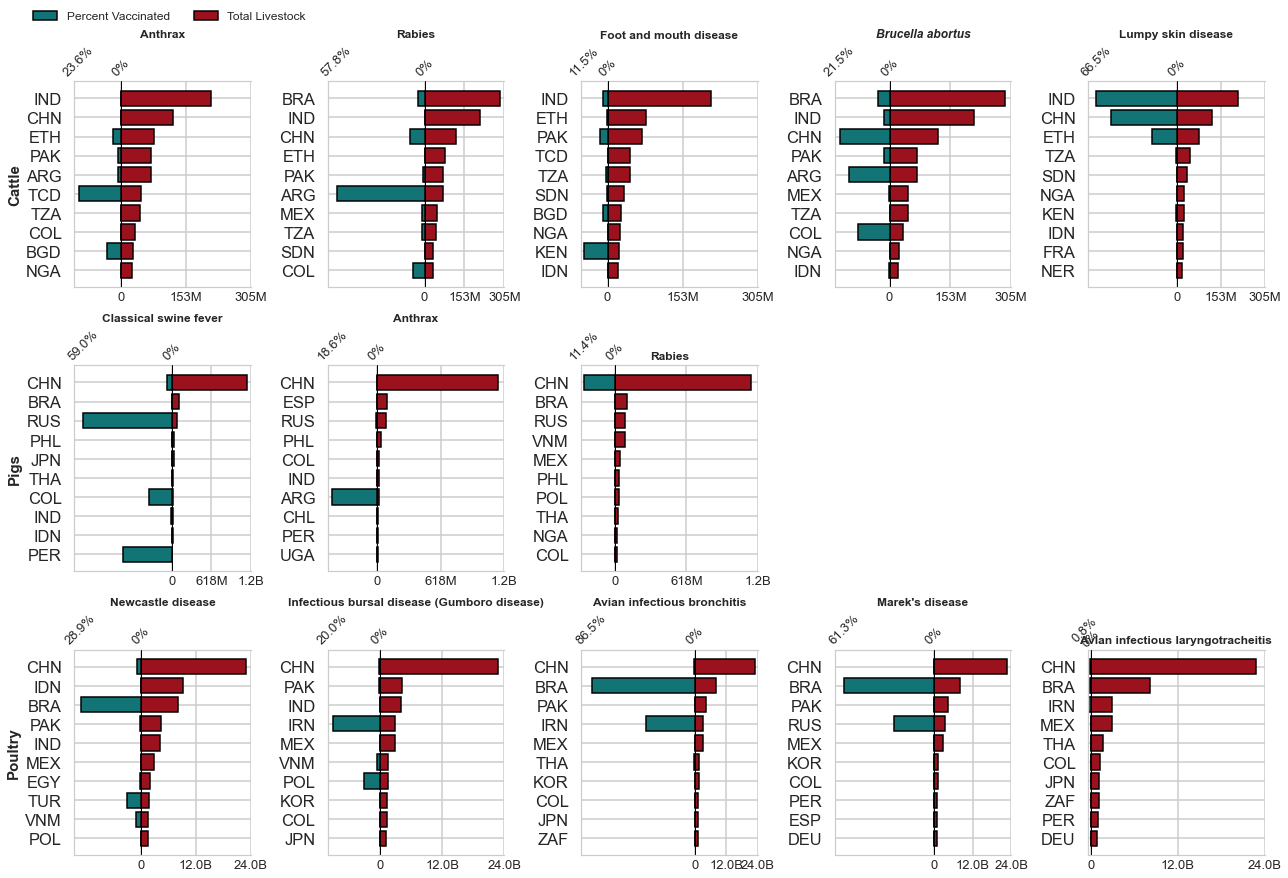

In [16]:
#Plot below is for unvaccinated gap scaled by production intensity


to_export_dfs=[]

total_color='#9B111E' # Imperial red
vacc_color = "#127475" # Deep cyan

def easier_format(num, pos):
    """
    Format large numbers into a more readable format.
    """
    if num >= 1_000_000_000:
        return f"{num/1_000_000_000:.1f}B"
    elif num >= 1_000_000:
        return f"{round(num/1_000_000)}M"
    elif num >= 1_000:
        return f"{round(num/1_000)}K"
    elif num >= 100:
        return f"{int(round(num, -2))}"
    else:
        return str(int(num))

def diverging_formatter_factory(s):
    def formatter(x, pos):
        if x < 0:
            return f"{abs(x)/s:.0f}%"
        else:
            return easier_format(x, pos)
    return formatter

df_2025 = df_calculations_vacc[df_calculations_vacc["Year"] == 2025].copy()

animal_groups = {"Cattle": [], "Pigs": [], "Poultry": []}
for disease in diseases_info:
    animal = disease["Animal"]
    if animal in animal_groups:
        animal_groups[animal].append(disease)
    else:
        animal_groups[animal] = [disease]

sns.set_style("whitegrid")
sns.set_context("talk", font_scale=1.0)
plt.rcParams["axes.linewidth"] = 1.2

cols = 5  
rows = len(animal_groups)
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4), sharex=False, sharey=False)
if rows == 1:
    axes = [axes]
else:
    axes = axes.reshape(rows, cols)
    
for row_idx, (animal, diseases) in enumerate(animal_groups.items()):
    group_max_total = df_2025[df_2025["Animal"] == animal]["total pop"].max()
    group_common_xlim_right = group_max_total * 1.05
    group_xticks = np.linspace(0, group_common_xlim_right, 3)
    group_xtick_labels = [easier_format(x, None) for x in group_xticks]

    if not diseases:
        for c in range(cols):
            axes[row_idx, c].set_visible(False)
        continue

    for col_idx in range(cols):
        if col_idx < len(diseases):
            disease_info = diseases[col_idx]
            disease_name = disease_info["Disease"]
            ax = axes[row_idx, col_idx]

            if 'castle' not in disease_name:
                df_disease = df_2025[
                    (df_2025["Disease"] == disease_name) & 
                    (df_2025["Animal"] == animal) & 
                    (df_2025["Status in livestock"] == "Present") &
                    (~df_2025["Source_x"].str.contains("Imputed", case=False, na=False))
                ]
            else:
                df_disease = df_2025[
                    (df_2025["Disease"] == disease_name) & 
                    (df_2025["Animal"] == animal) & 
                    (df_2025["Status in livestock"] == "Present") &
                    (~df_2025["Source_x"].str.contains("Imputed", case=False, na=False))
                ]
                

                
            df_disease=df_disease[(df_disease['Status in livestock']=='Present')]

                
            df_disease["Unvaccinated"] = df_disease["total pop"] - df_disease["Number of Vaccinated Estimate"]

            top_countries = df_disease.nlargest(10, "Unvaccinated").copy()
            if top_countries.empty:
                ax.set_visible(False)
                continue

            max_total = top_countries['total pop'].max()
            scale_factor = 10 * (max_total * 0.2 / 100)
            common_xlim_right = group_common_xlim_right  

            top_countries["vacc_percent"] = (
                top_countries["Number of Vaccinated Estimate"] / top_countries["total pop"] * 100
            )
            to_export_dfs.append(top_countries)
            top_countries.sort_values("total pop", ascending=False, inplace=True)

            local_max = top_countries["vacc_percent"].max()

            # Label the leftmost subplot in each row with the animal name.
            if col_idx == 0:
                ax.set_ylabel(animal, fontsize=15, fontweight='bold')
            else:
                ax.set_ylabel("")
            display_max = local_max

            local_xlim_left = - (local_max * scale_factor * 1.05)

            ax.set_xlim(local_xlim_left * 1.05, common_xlim_right)

            ax.set_xticks(group_xticks)
            ax.set_xticklabels(group_xtick_labels, fontsize=13)  # increased font size for tick labels
            ax.xaxis.set_major_formatter(mtick.FuncFormatter(diverging_formatter_factory(scale_factor)))
            ax.tick_params(axis='x', which='major', length=0, width=0, direction='in', rotation=0, labelsize=13)

            # SECONDARY X-AXIS (top): Vaccinated (%).
            # These ticks reflect the blue bars (vaccinated %) on the negative side.
            secax = ax.secondary_xaxis('top')
            secax.set_xlim(-1 * (-local_xlim_left) * 1.05, 0)
            
            if local_max > 1.1:
                secax.set_xticks([-1 * (local_max * scale_factor), 0])            
                secax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
                secax.set_xticklabels([f"{local_max:.1f}%", f"{0}%"], fontsize=13)
            else:
                tick_pos = -1 * (local_max * scale_factor)
                secax.set_xticks([tick_pos, 0])
                secax.set_xticklabels(["", ""])
                ax.text(tick_pos * 2.5, 1.025, f"{local_max:.1f}%", 
                        ha='center', va='bottom', fontsize=13, rotation=45,
                        transform=ax.get_xaxis_transform())
                ax.text(0, 1.0, f"{0}%", 
                        ha='center', va='bottom', fontsize=13, rotation=45,
                        transform=ax.get_xaxis_transform())

            secax.tick_params(axis='x', rotation=45, length=0, width=0, labelsize=13)

            ax.axvline(0, color="black", linewidth=1)
            ax.invert_yaxis()
            
            if disease_name == "Brucella abortus (Inf. with)":
                ax.set_title("Brucella abortus", fontsize=12, fontweight="bold", fontstyle="italic")
            else:
                title_text = disease_name.replace(' (Inf. with)', '').replace(' (-2011)', '').replace(' virus','')
                if title_text.strip().lower() == "rabies" and animal.lower() == "pigs":
                    ax.set_title(title_text, fontsize=12, fontweight='bold',y=1)
                else:
                    ax.set_title(title_text, fontsize=12, fontweight='bold')
                

            ax.barh(top_countries["ISO3"], top_countries["total pop"],
                    color=total_color, edgecolor="black", label="Total Livestock")
            ax.barh(top_countries["ISO3"], - top_countries["vacc_percent"] * scale_factor,
                    color=vacc_color, edgecolor="black", label="Percent Vaccinated")
        else:
            axes[row_idx, col_idx].set_visible(False)

handles, labels = [], []
for row in axes:
    for ax in row:
        if ax.get_visible():
            handles, labels = ax.get_legend_handles_labels()
            if handles and labels:
                break
    if handles and labels:
        break

handles, labels = handles[::-1], labels[::-1]

fig.legend(handles, labels, ncol=2, loc="upper left", bbox_to_anchor=(0.02, 1.02),
           frameon=False, fontsize=12)

sns.despine(fig=fig, left=False, bottom=False)
plt.tight_layout()

plt.show()


In [17]:
ZWS = "\u200B"          # zero-width space (Word wraps here, no visible gap)
TOKEN_BREAK_LEN = 10    
INSERT_EVERY = 7        

def insert_wrap_spaces_in_long_tokens(text: str) -> str:
    """
    Insert wrap points inside long unbreakable tokens so Word can wrap.
    """
    if not isinstance(text, str):
        return "" if pd.isna(text) else str(text)
    spacer = ZWS

    parts = re.split(r"([\s\-/·,()])", text)
    out = []
    for part in parts:
        if re.fullmatch(r"[\s\-/·,()]", part) or len(part) < TOKEN_BREAK_LEN:
            out.append(part)
            continue
        chunks = [part[i:i+INSERT_EVERY] for i in range(0, len(part), INSERT_EVERY)]
        out.append(spacer.join(chunks))
    return "".join(out)


def add_scientific_notation(paragraph, value, precision=2):
    if pd.isnull(value):
        paragraph.add_run("")
        return
    formatted = f"{value:.{precision}e}"
    base, exponent = formatted.split('e')
    exponent_int = int(exponent)
    run1 = paragraph.add_run(f"{base} x 10")
    run1.font.size = Pt(8.5)
    run2 = paragraph.add_run(str(exponent_int))
    run2.font.superscript = True
    run2.font.size = Pt(8.5)

poultry_most_countries, cattle_most_countries, pigs_most_countries = [], [], []
doc = Document()

for df in to_export_dfs:
    df = df[df['Year'] == 2025].copy()
    if df.empty:
        continue

    animal = df['Animal'].values[0]
    disease_name = df['Disease'].values[0]

    df['Number of Unvaccinated Estimate'] = df['total pop'] - df['Number of Vaccinated Estimate']

    prelim = df.loc[:, [
        'Country','Vaccination Coverage (%)','Year Data_x','total pop',
        'Number of Unvaccinated Estimate',
        'Aggregate of Latest Reported Cases (up to Year)',
        'Estimated (Scaled) Cases','Year Data_y'
    ]].copy()

    prelim.rename(columns={
        'total pop': 'Population (living + slaughtered)',
        'Vaccination Coverage (%)': 'Vaccination Coverage Estimate (%)',
        'Year Data_x': 'Year Coverage Data',
        'Number of Unvaccinated Estimate': 'Number of Unvaccinated (living + slaughtered)',
        'Year Data_y': 'Year Cases Data'
    }, inplace=True)

    for col in [
        'Number of Unvaccinated (living + slaughtered)',
        'Population (living + slaughtered)',
        'Estimated (Scaled) Cases',
        'Aggregate of Latest Reported Cases (up to Year)'
    ]:
        if col in prelim:
            prelim[col] = pd.to_numeric(prelim[col], errors='coerce').round(0).astype('Int64')
    if 'Vaccination Coverage Estimate (%)' in prelim:
        prelim['Vaccination Coverage Estimate (%)'] = pd.to_numeric(
            prelim['Vaccination Coverage Estimate (%)'], errors='coerce'
        ).round(2)

    countries_list = prelim['Country'].dropna().astype(str).tolist()
    if animal.lower() == 'poultry':
        poultry_most_countries += countries_list
    elif animal.lower() == 'cattle':
        cattle_most_countries += countries_list
    elif animal.lower() == 'pigs':
        pigs_most_countries += countries_list

    # clean disease names
    if 'virus' in disease_name: disease_name = disease_name.replace(' virus', '')
    if '(Inf. with)' in disease_name: disease_name = disease_name.replace(' (Inf. with)', '')
    disease_name = re.sub(r" [\(\[]-\d{4}[\)\]]", "", disease_name).title()
    if disease_name == 'Haemorrhagic Septicaemia (Pasteurella Multocida Serotypes 6:B And 6:E)':
        disease_name = 'Haemorrhagic Septicaemia'
    if disease_name == "Marek'S Disease": disease_name = "Marek's Disease"

    prelim = prelim.reset_index(drop=True)

    # sort and take top 10
    df_top = (prelim.sort_values(by=['Number of Unvaccinated (living + slaughtered)'], ascending=False)
                    .head(10)
                    .reset_index(drop=True))

    sentence = (
        f"Top ten countries that have {disease_name} present/suspected in {animal}, "
        f"by total number of unvaccinated animals in 2025, scaled by production intensity "
        f"(living + slaughtered populations)."
    )
    paragraph = doc.add_paragraph(sentence)
    paragraph.alignment = WD_PARAGRAPH_ALIGNMENT.LEFT

    table = doc.add_table(rows=1, cols=len(df_top.columns))
    table.style = 'Table Grid'

    # header row
    hdr_cells = table.rows[0].cells
    for i, column in enumerate(df_top.columns):
        hdr_cells[i].text = str(column)
        if hdr_cells[i].paragraphs[0].runs:
            run = hdr_cells[i].paragraphs[0].runs[0]
        else:
            run = hdr_cells[i].paragraphs[0].add_run()
        run.font.bold = True
        run.font.size = Pt(9.5)

    # body rows
    special_cols = ['Population (living + slaughtered)', 'Number of Unvaccinated (living + slaughtered)']
    for _, row in df_top.iterrows():
        row_cells = table.add_row().cells
        for i, col in enumerate(df_top.columns):
            row_cells[i].text = ""
            p = row_cells[i].paragraphs[0]
            if col == 'Country':
                val = "" if pd.isna(row[col]) else str(row[col])
                wrapped = insert_wrap_spaces_in_long_tokens(val)
                run = p.add_run(wrapped)
                run.font.size = Pt(8.5)
            elif col in special_cols:
                add_scientific_notation(p, row[col], precision=2)
            else:
                run = p.add_run("" if pd.isna(row[col]) else str(row[col]))
                run.font.size = Pt(8.5)

    doc.add_paragraph("\n")
    doc.add_page_break()

doc.save("top_countries_unvaccinated_gap_scaled_production_cycle.docx")

In [18]:
Counter(cattle_most_countries).most_common()

[('India', 5),
 ('Tanzania, United Republic of', 5),
 ('China', 4),
 ('Ethiopia', 4),
 ('Pakistan', 4),
 ('Nigeria', 4),
 ('Argentina', 3),
 ('Colombia', 3),
 ('Sudan', 3),
 ('Indonesia', 3),
 ('Chad', 2),
 ('Bangladesh', 2),
 ('Brazil', 2),
 ('Mexico', 2),
 ('Kenya', 2),
 ('France', 1),
 ('Niger', 1)]

In [19]:
Counter(pigs_most_countries).most_common()

[('China', 3),
 ('Russian Federation', 3),
 ('Philippines', 3),
 ('Colombia', 3),
 ('Brazil', 2),
 ('Thailand', 2),
 ('India', 2),
 ('Peru', 2),
 ('Japan', 1),
 ('Indonesia', 1),
 ('Spain', 1),
 ('Argentina', 1),
 ('Chile', 1),
 ('Uganda', 1),
 ('Viet Nam', 1),
 ('Mexico', 1),
 ('Poland', 1),
 ('Nigeria', 1)]

In [20]:
Counter(poultry_most_countries).most_common()

[('China', 5),
 ('Mexico', 5),
 ('Brazil', 4),
 ('Pakistan', 4),
 ('Colombia', 4),
 ('Iran, Islamic Republic of', 3),
 ('Korea, Republic of', 3),
 ('Japan', 3),
 ('India', 2),
 ('Viet Nam', 2),
 ('Poland', 2),
 ('Thailand', 2),
 ('South Africa', 2),
 ('Peru', 2),
 ('Germany', 2),
 ('Indonesia', 1),
 ('Egypt', 1),
 ('Türkiye, Republic of', 1),
 ('Russian Federation', 1),
 ('Spain', 1)]